In [2]:
from langgraph.graph import StateGraph, START, END

from typing_extensions import TypedDict, NotRequired
from pydantic import BaseModel, Field

from spm_agent.mcp.spm_mcp_client import SPMMCPClient

from pprint import pprint
import json

In [3]:
class ScannerCalibrations(BaseModel, frozen=True):
    """
    One-point calibration relating the piezo scanner voltage (LVDT) coordinate
    system to the scan-frame (XOffset/YOffset) coordinate system.

    scanner_offset = lvdt_position - scan_center, both measured
    at the same physical point (tip parked at the scan-frame center by
    calibrate_xy_frame). Therefore:
        frame_coord   = lvdt_coord  - scanner_offset
        lvdt_coord    = frame_coord + scanner_offset

    Sensitivities are stored so sync can detect instrument
    reconfiguration by comparing against live XLVDTSens/YLVDTSens.
    Internal state - never rendered into LLM context.
    """
    x_scanner_offset_m: float
    y_scanner_offset_m: float
    x_lvdt_sens_m_per_v: float
    y_lvdt_sens_m_per_v: float

class ScanSettings(BaseModel, frozen=True):
    """Geometry and acquisition properties of the scan frame."""
    x_scan_center_m: float = Field(description="X center of the scan frame in meters")
    y_scan_center_m: float = Field(description="Y center of the scan frame in meters")
    scan_size_m: float = Field(description="Size (side length) of the scan frame in meters")
    pixels: int = Field(description="Number of pixels (per side) in the scan frame")
    scan_rate_hz: float = Field(description="Scan acquisition rate in Hz, i.e. number of lines per second")

class ProbePosition(BaseModel, frozen=True):
    x_m: float = Field(description="X position of the probe in meters, same coordinate system as the 'ScanSettings.x_scan_center_m' and 'ScanSettings.y_scan_center_m' fields")
    y_m: float = Field(description="Y position of the probe in meters, same coordinate system as the 'ScanSettings.x_scan_center_m' and 'ScanSettings.y_scan_center_m' fields")

class PFMExcitation(BaseModel, frozen=True):
    drive_amplitude_v: float = Field(description="AC excitation amplitude on the probe in volts")
    drive_frequency_hz: float = Field(description="Center frequency of the DART dual-frequency drive, Hz.")
    dart_width_hz: float = Field(description = "Width of the frequency window, separating the two drive frequencies, Hz. (f1,2 = drive_frequency_hz +/- dart_width_hz/2)")

class ContactFeedback(BaseModel, frozen=True):
    setpoint_v: float = Field(description="Deflection setpoint in volts, that determines the desired probe-sample contact force")
    gain: float = Field(description="Integral gain of the feedback loop controlling the probe height")

class InstrumentState(BaseModel, frozen=True):
    scan_settings: ScanSettings
    probe_position: ProbePosition
    pfm_excitation: PFMExcitation
    contact_feedback: ContactFeedback

class PFMExperimentState(TypedDict):
    """State of the PFM experiment, including the instrument state and the acquired data."""
    instrument_state: InstrumentState #current instrument parameter snapshot
    scanner_calibrations: ScannerCalibrations #define one time per session 
    


In [29]:
def to_scanner_calibration_state(state_dict: dict)-> ScannerCalibrations:
    scanner_calibration = ScannerCalibrations(
        x_scanner_offset_m = state_dict['x_lvdt_m'] - state_dict['x_scan_center_m'],
        y_scanner_offset_m = state_dict['y_lvdt_m'] - state_dict['y_scan_center_m'],
        x_lvdt_sens_m_per_v = state_dict['x_lvdt_sens_m_per_v'],
        y_lvdt_sens_m_per_v = state_dict['y_lvdt_sens_m_per_v']
    )

    return scanner_calibration

def to_instrument_state(
        state_dict :dict,
        scanner_calibrations: ScannerCalibrations | None
        )-> InstrumentState:
    
    #probe position
    x_m, y_m = None, None
    
    x_probe_lvdt_m, y_probe_lvdt_m = state_dict.get("x_probe_lvdt_m"), state_dict.get("y_probe_lvdt_m")
    if scanner_calibrations is not None:
        x_m = x_probe_lvdt_m - scanner_calibrations.x_scanner_offset_m
        y_m = y_probe_lvdt_m - scanner_calibrations.y_scanner_offset_m

    probe_position = ProbePosition(
        x_m = x_m,
        y_m = y_m
    )
    
    scan_settings = ScanSettings(
        x_scan_center_m=state_dict["x_scan_center_m"],
        y_scan_center_m=state_dict["y_scan_center_m"],
        scan_size_m = state_dict['scan_size_m'],
        pixels = state_dict['n_points'],
        scan_rate_hz = state_dict['scan_rate_hz'],
    )

    pfm_excitation = PFMExcitation(
        drive_amplitude_v = state_dict["v_ac_v"],
        drive_frequency_hz = state_dict['f_dart_hz'],
        dart_width_hz = state_dict["f_dart_width_hz"],
    )

    contact_feedback = ContactFeedback(
        setpoint_v = state_dict['setpoint_defl_v'],
        gain = state_dict['igain']
    )
    
    return InstrumentState(
        probe_position = probe_position,
        scan_settings = scan_settings,
        pfm_excitation = pfm_excitation,
        contact_feedback = contact_feedback,
    )




In [30]:
async def get_scanner_calibrations_node(state: PFMExperimentState) -> PFMExperimentState:
    spm_client = SPMMCPClient()
    result = await spm_client.call_tool("pfm_calibrate_xy_frame")
    res_dict = json.loads(result[0]['text'])

    if res_dict['ok']:
        state_dict = res_dict['data']
        scanner_calibrations = to_scanner_calibration_state(state_dict)
    
    return {
        "scanner_calibrations": scanner_calibrations
    }

async def get_status_node(state: PFMExperimentState) -> PFMExperimentState:
    spm_client = SPMMCPClient()
    result = await spm_client.call_tool("pfm_get_experiment_status")
    res_dict = json.loads(result[0]['text'])

    if res_dict['ok']:
        state_dict = res_dict['data']
        instrument_state = to_instrument_state(
            state_dict,
            scanner_calibrations=state['scanner_calibrations']
            )
    
    return {
        "instrument_state": instrument_state
    }

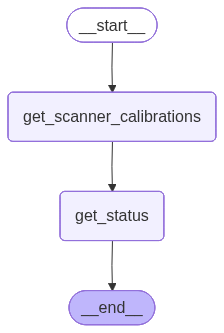

In [31]:
builder = StateGraph(PFMExperimentState)
builder.add_node('get_scanner_calibrations', get_scanner_calibrations_node)
builder.add_node('get_status', get_status_node)

builder.add_edge(START, 'get_scanner_calibrations')
builder.add_edge('get_scanner_calibrations', 'get_status')
builder.add_edge('get_status', END)

graph = builder.compile()
graph 

In [32]:
result = await graph.ainvoke({})

In [34]:
pprint(result)

{'instrument_state': InstrumentState(scan_settings=ScanSettings(x_scan_center_m=3.7070408e-06, y_scan_center_m=9.863858e-08, scan_size_m=9.9999997e-06, pixels=256, scan_rate_hz=0.70067263), probe_position=ProbePosition(x_m=3.707040799999999e-06, y_m=9.863857999999997e-08), pfm_excitation=PFMExcitation(drive_amplitude_v=0.5, drive_frequency_hz=401166.19, dart_width_hz=10000.0), contact_feedback=ContactFeedback(setpoint_v=0.5, gain=40.0)),
 'scanner_calibrations': ScannerCalibrations(x_scanner_offset_m=-1.797207858894784e-05, y_scanner_offset_m=1.554795885260358e-05, x_lvdt_sens_m_per_v=9.2639584e-06, y_lvdt_sens_m_per_v=9.9031586e-06)}


In [19]:
spm_client = SPMMCPClient()
result = await spm_client.call_tool("pfm_get_experiment_status")

In [40]:
pprint(result['instrument_state'].probe_position)  
pprint(result['instrument_state'].scan_settings)  

ProbePosition(x_m=3.707040799999999e-06, y_m=9.863857999999997e-08)
ScanSettings(x_scan_center_m=3.7070408e-06, y_scan_center_m=9.863858e-08, scan_size_m=9.9999997e-06, pixels=256, scan_rate_hz=0.70067263)


In [11]:
res_dict = json.loads(result[0]['text'])

In [62]:
g_res['scanner_calibrations'].x_scanner_offset_m

-1.797207858894784e-05

In [16]:
to_instrument_state(res_dict['data'], g_res['scanner_calibrations'])

(3.707040799999999e-06, 9.863857999999997e-08)

In [15]:
res_dict.keys()

dict_keys(['ok', 'data', 'audit'])